# Probe Quality & Direction Certification (E1)

Validates the harmfulness **direction** `v_harmful` before trusting its downstream use in nb04–08 and the circuit-breakers study (nb09).

`v_harmful` is not a trained probe — it's a closed-form unit vector computed by within-pair subtraction on JBB's topic-paired structure. The question is whether that direction actually captures *harmfulness* rather than *topic*, *attacker style*, or other label-correlated artefacts.

**Checks 1–6** are descriptive sanity (topic leakage, direction comparison, LPOCV, per-category AUROC, pair-wise ranking, single-turn sanity).
**Checks 7–10** are formal certifications with pre-declared falsification thresholds. See `docs/experiment_plan.md` §E1.

| # | Check | What it answers | Threshold |
|---|-------|-----------------|-----------|
| 1 | Topic leakage | Does projection onto v_harmful predict JBB category? | R² < 0.15 at mid layers |
| 2 | Direction comparison | Paired vs unpaired vs PCA vs random | paired best on AUROC, low R² |
| 3 | Leave-pair-out CV | Generalizes to held-out topics? | gap < 0.05 vs standard |
| 4 | Per-category AUROC | Signal uniform across categories? | > 0.7 for ≥ 8/10 cats |
| 5 | Pair-wise ranking | proj(harm) > proj(benign) per pair | > 0.85 |
| 6 | Single-turn sanity | v_ST separates 100 vs 100 ST prompts | AUROC > 0.95 |
| **7** | **Bootstrap CIs** | 95% CI on AUROC, conversation-level resample | CI excludes 0.5 at mid layers |
| **8** | **Topic-orthogonalization** | AUROC after projecting out v_topic | orthogonalized AUROC ≥ 0.70 |
| **9** | **Label-randomization null** | AUROC under within-pair label shuffle | null AUROC ∈ [0.48, 0.52] |
| **10** | **Layer-robustness band** | AUROC across mid-depth layer block | mid-band min AUROC ≥ 0.70 |

All checks at `h_inst` (primary position). Change `H_KEY` in cell 2 to rerun at `h_post_inst`.
Set `MODEL` at the top to switch between llama / qwen / gemma.


## 1. Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

MODEL = 'llama'                         # model subdirectory under data/
H_KEY = 'h_inst'                        # 'h_inst' or 'h_post_inst'

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT = repo_root / 'data' / MODEL / 'representations'
FIG_DIR   = repo_root / 'figures'
FIG_DIR.mkdir(exist_ok=True)

FRAMEWORKS        = ['crescendo', 'actorattack', 'xteaming']
TRAIN_MAX_ATTEMPT = 16
RNG_SEED          = 42

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'MODEL={MODEL}  H_KEY={H_KEY}')

# ── Load per-model layer sweep from layer_indices.json ──────────────────────
# After the down-select, saved arrays have shape (N, 8, D). layer_indices.json
# sits next to each (fw_split) directory with the original transformer-layer IDs.
import json as _json

def _load_layer_info(model_root):
    for sub in ("trajectories", "nocontext", "single_turn"):
        root = model_root / sub
        if not root.exists():
            continue
        for d in root.iterdir():
            fp = d / "layer_indices.json"
            if fp.exists():
                return _json.loads(fp.read_text())
    raise FileNotFoundError(
        f"No layer_indices.json under {model_root} — run scripts/downselect_layers.py"
    )

_LAYER_INFO        = _load_layer_info(REPR_ROOT)
N_SAVED_LAYERS     = _LAYER_INFO["n_sweep"]
VERIFY_LAYERS      = list(range(N_SAVED_LAYERS))       # saved-array positions 0..7
VERIFY_LABELS      = _LAYER_INFO["labels"]             # e.g. ["L1", "L5", "L9", ...]
N_VERIFY           = N_SAVED_LAYERS
FOCAL_LAYER        = N_SAVED_LAYERS - 1                # last saved layer (deepest); was L32 on Llama
FOCAL_LAYER_LABEL  = VERIFY_LABELS[FOCAL_LAYER]
ALL_LAYERS         = VERIFY_LAYERS                     # full sweep as saved
print(f"Saved-layer sweep: {VERIFY_LABELS}  |  focal={FOCAL_LAYER_LABEL}")


MODEL=llama  H_KEY=h_inst
Saved-layer sweep: ['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']  |  focal=L32


/Users/lisahusieva/Desktop/multi-turn-rep-eng/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def subset(h, meta, mask):
    """Return aligned (h_subset, meta_subset) with fresh index."""
    mask = mask.values if hasattr(mask, 'values') else mask
    return h[mask], meta[mask].reset_index(drop=True)

def paired_direction(h, meta, layer):
    """Within-pair subtraction: mean over pairs of (mean_harmful − mean_benign)."""
    diffs = []
    for pair_id, grp in meta.groupby('pair_id'):
        idx_h = grp.index[grp['goal_type'] == 'harmful'].tolist()
        idx_b = grp.index[grp['goal_type'] == 'benign'].tolist()
        if not idx_h or not idx_b:
            continue
        mu_h = np.asarray(h[idx_h, layer, :], dtype=np.float32).mean(0)
        mu_b = np.asarray(h[idx_b, layer, :], dtype=np.float32).mean(0)
        diffs.append(mu_h - mu_b)
    if not diffs:
        return None
    d = np.stack(diffs).mean(0)
    return d / (np.linalg.norm(d) + 1e-12)

def unpaired_direction(h, meta, layer):
    """Naive: mean(h | harmful) − mean(h | benign). Ignores pair structure."""
    idx_h = meta.index[meta['goal_type'] == 'harmful'].tolist()
    idx_b = meta.index[meta['goal_type'] == 'benign'].tolist()
    if not idx_h or not idx_b:
        return None
    mu_h = np.asarray(h[idx_h, layer, :], dtype=np.float32).mean(0)
    mu_b = np.asarray(h[idx_b, layer, :], dtype=np.float32).mean(0)
    d = mu_h - mu_b
    return d / (np.linalg.norm(d) + 1e-12)

def pca_direction(h, layer):
    """Top PCA component of the centred activations — pure variance direction."""
    X = np.asarray(h[:, layer, :], dtype=np.float32)
    pca = PCA(n_components=1).fit(X - X.mean(0, keepdims=True))
    d = pca.components_[0]
    return d / (np.linalg.norm(d) + 1e-12)

def random_direction(dim, seed=0):
    rng = np.random.default_rng(seed)
    d = rng.standard_normal(dim).astype(np.float32)
    return d / np.linalg.norm(d)

def project(h, direction, layer):
    return np.asarray(h[:, layer, :], dtype=np.float32) @ direction

def auroc_on(h, meta, direction, layer, label_col='goal_type', pos_class='harmful'):
    proj = project(h, direction, layer)
    y = (meta[label_col] == pos_class).astype(int).values
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, proj)

def topic_r2(h, meta, direction, layer, cat_col='category'):
    """R² of scalar projection regressed on one-hot category — topic leakage."""
    proj = project(h, direction, layer)
    X = pd.get_dummies(meta[cat_col].values).values.astype(np.float32)
    if X.shape[1] < 2:
        return np.nan
    return LinearRegression().fit(X, proj).score(X, proj)

def precompute_pair_means(h, meta, layer, split_value='train'):
    """{pair_id: {'harmful': mean, 'benign': mean}} — for leave-pair-out."""
    out = {}
    sub = meta[meta['data_split'] == split_value]
    for pair_id, grp in sub.groupby('pair_id'):
        entry = {}
        for gtype in ['harmful', 'benign']:
            idxs = grp.index[grp['goal_type'] == gtype].tolist()
            if idxs:
                entry[gtype] = np.asarray(h[idxs, layer, :], dtype=np.float32).mean(0)
        if 'harmful' in entry and 'benign' in entry:
            out[pair_id] = entry
    return out

def direction_from_pair_means(pair_means, exclude=None):
    diffs = [m['harmful'] - m['benign'] for p, m in pair_means.items() if p != exclude]
    d = np.stack(diffs).mean(0)
    return d / (np.linalg.norm(d) + 1e-12)

print('Helpers defined.')

Helpers defined.


In [3]:
# ── Load final-turn representations from each framework ──────────────────────

from datasets import load_dataset

# pair_id → JBB harm category (trajectory meta doesn't carry category)
jbb = load_dataset('JailbreakBench/JBB-Behaviors', 'behaviors')
PAIR_TO_CATEGORY = {}
for split in ['harmful', 'benign']:
    for row in jbb[split]:
        PAIR_TO_CATEGORY[int(row['Index'])] = row['Category']

def load_final_turn(fw, split):
    d = REPR_ROOT / 'trajectories' / f'{fw}_{split}'
    if not d.exists():
        return None
    meta = pd.read_parquet(d / 'metadata.parquet')
    h = np.load(str(d / f'{H_KEY}.npy'), mmap_mode='r')
    final_idx = meta.groupby('conversation_id')['turn_k'].idxmax().values
    meta = meta.loc[final_idx].reset_index(drop=True)
    if 'category' not in meta.columns:
        meta['category'] = meta['pair_id'].map(PAIR_TO_CATEGORY)
    return h[final_idx], meta

combined = {}
for fw in FRAMEWORKS:
    outs = {sp: load_final_turn(fw, sp) for sp in ['harmful', 'benign']}
    if outs['harmful'] is None or outs['benign'] is None:
        print(f'  [skip] {fw} — trajectories not found')
        continue
    h = np.concatenate([outs['harmful'][0], outs['benign'][0]], axis=0)
    meta = pd.concat([
        outs['harmful'][1].assign(goal_type='harmful'),
        outs['benign'][1].assign(goal_type='benign'),
    ], ignore_index=True)
    meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
    combined[fw] = {'h': h, 'meta': meta}
    print(f'  {fw:14s} rows={len(meta):5d}  train={(meta["data_split"]=="train").sum():5d}  test={(meta["data_split"]=="test").sum():5d}  categories={meta["category"].nunique()}')

assert combined, f'No trajectory data found under {REPR_ROOT / "trajectories"}'

n_layers   = combined[next(iter(combined))]['h'].shape[1]
hidden_dim = combined[next(iter(combined))]['h'].shape[2]
VERIFY_LAYERS = np.linspace(0, n_layers - 1, 8).astype(int).tolist()

print(f'\nn_layers={n_layers}  hidden_dim={hidden_dim}  sweep={VERIFY_LABELS}')


  crescendo      rows= 3985  train= 3191  test=  794  categories=10
  actorattack    rows= 3995  train= 3196  test=  799  categories=10
  xteaming       rows= 3944  train= 3156  test=  788  categories=10

n_layers=8  hidden_dim=4096  sweep=['L1', 'L5', 'L9', 'L14', 'L18', 'L23', 'L27', 'L32']


## 2. Check 1 — Topic leakage

If the scalar projection onto `v_harmful` predicts JBB category (R² high), the direction is contaminated with topic signal. Paired subtraction should drive R² down relative to unpaired.

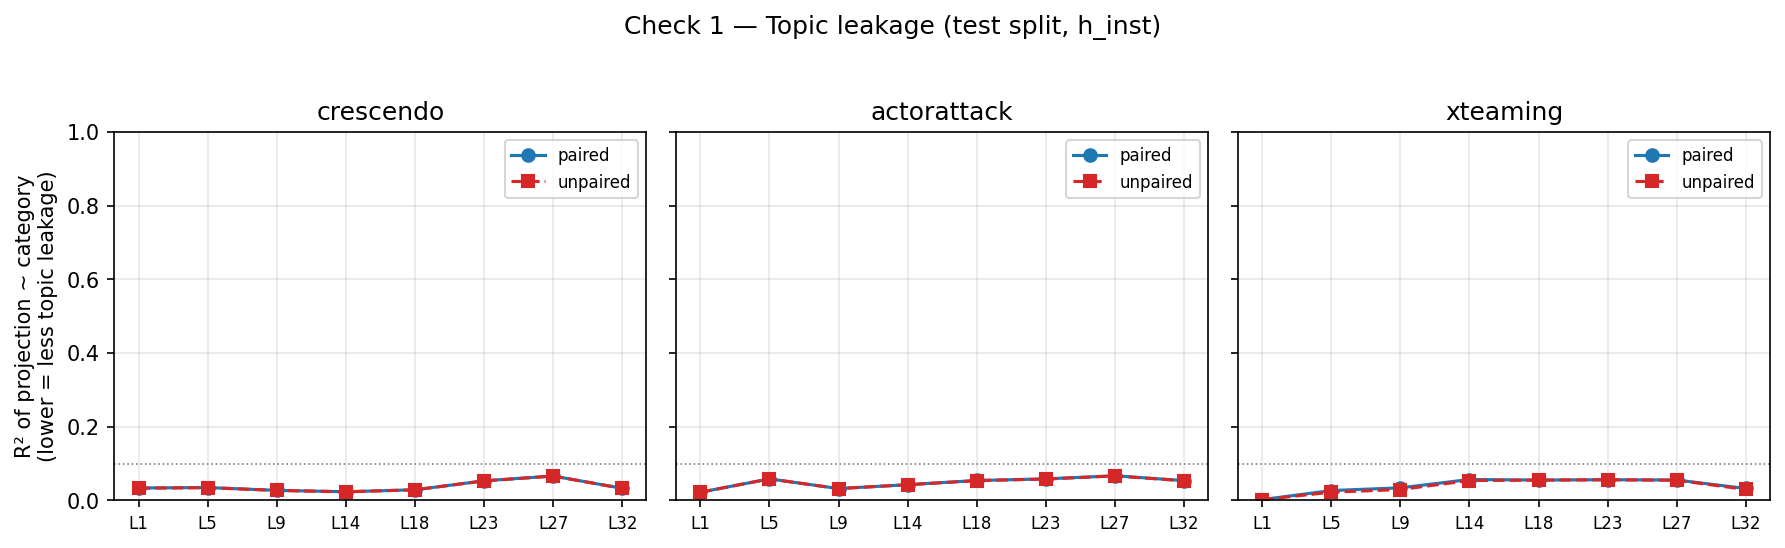

,framework,R2_paired_mean,R2_unpaired_mean
0,crescendo,0.037584,0.037339
1,actorattack,0.048587,0.048321
2,xteaming,0.039873,0.037958


In [4]:
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5),
                         sharey=True, squeeze=False)
check1_summary = []

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    r2_paired, r2_unpaired = [], []
    for li in VERIFY_LAYERS:
        v_p = paired_direction(h_tr, m_tr, li)
        v_u = unpaired_direction(h_tr, m_tr, li)
        r2_paired.append(topic_r2(h_te, m_te, v_p, li))
        r2_unpaired.append(topic_r2(h_te, m_te, v_u, li))

    ax.plot(range(len(VERIFY_LAYERS)), r2_paired, 'o-', color='#1f77b4', label='paired')
    ax.plot(range(len(VERIFY_LAYERS)), r2_unpaired, 's--', color='#d62728', label='unpaired')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(0.1, color='gray', ls=':', lw=0.8)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('R² of projection ~ category\n(lower = less topic leakage)')
    check1_summary.append({
        'framework': fw,
        'R2_paired_mean':  float(np.mean(r2_paired)),
        'R2_unpaired_mean': float(np.mean(r2_unpaired)),
    })

fig.suptitle(f'Check 1 — Topic leakage (test split, {H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig1_topic_leakage_{H_KEY}.png')
plt.show()

pd.DataFrame(check1_summary)

## 3. Check 2 — Direction comparison (paired / unpaired / PCA / random)

Four directions compared side by side on the same evaluation data. Expected ordering:

- **Paired** AUROC highest, topic R² lowest — the intended behavior.
- **Unpaired** AUROC similar or slightly lower, topic R² higher — topic leaks in.
- **PCA** AUROC near 0.5 on the harmful/benign task but topic R² *high* — finds variance, which is mostly topic.
- **Random** AUROC ~ 0.5, topic R² ~ 0.1 — the null.

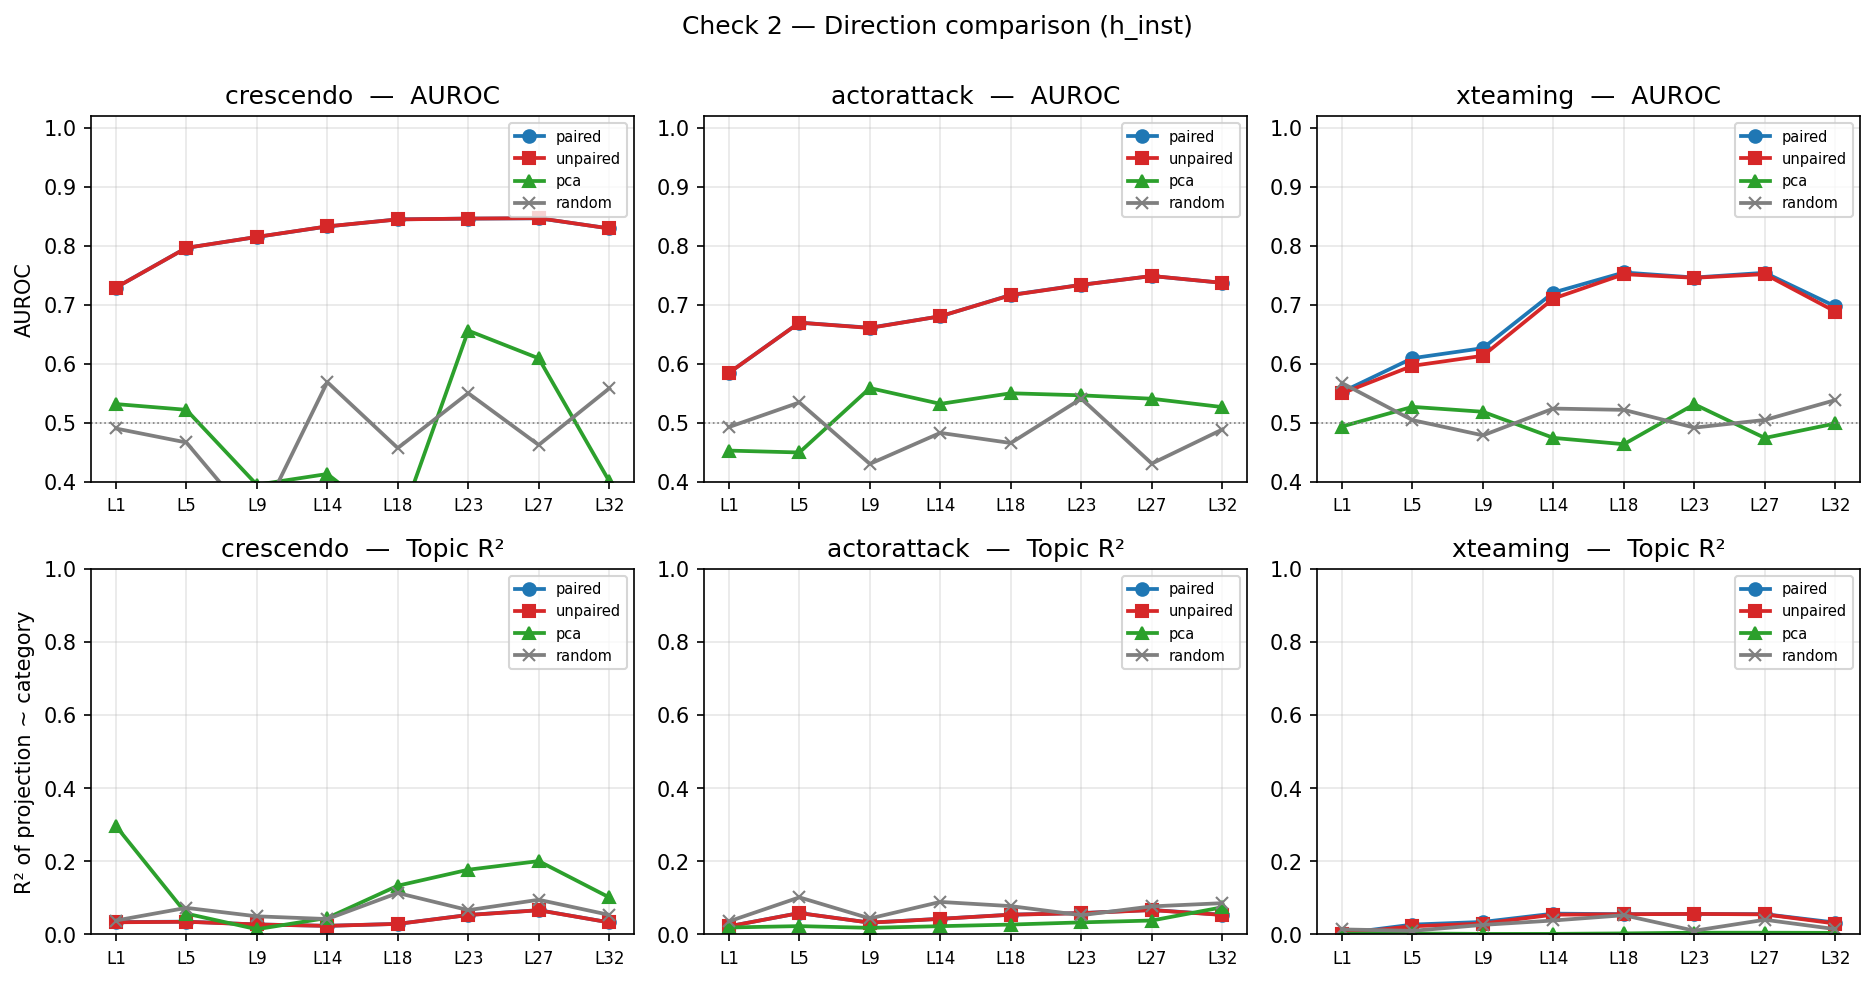

,framework,direction,best_layer,AUROC_best,R2_at_best_layer
0,crescendo,paired,L27,0.846678,0.066304
1,crescendo,unpaired,L27,0.846912,0.066008
2,crescendo,pca,L23,0.656339,0.176823
3,crescendo,random,L14,0.569168,0.042043
4,actorattack,paired,L27,0.748885,0.066894
5,actorattack,unpaired,L27,0.748935,0.066470
6,actorattack,pca,L9,0.558991,0.017980
7,actorattack,random,L23,0.541140,0.052474
8,xteaming,paired,L18,0.754871,0.055267
9,xteaming,unpaired,L27,0.752049,0.054767


In [5]:
fig, axes = plt.subplots(2, len(combined), figsize=(4.2 * len(combined), 6.5), squeeze=False)
check2_rows = []

for j, (fw, d) in enumerate(combined.items()):
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    aurocs = {k: [] for k in ['paired', 'unpaired', 'pca', 'random']}
    r2s    = {k: [] for k in ['paired', 'unpaired', 'pca', 'random']}

    for li in VERIFY_LAYERS:
        directions = {
            'paired':   paired_direction(h_tr, m_tr, li),
            'unpaired': unpaired_direction(h_tr, m_tr, li),
            'pca':      pca_direction(h_tr, li),
            'random':   random_direction(hidden_dim, seed=RNG_SEED + li),
        }
        for k, v in directions.items():
            aurocs[k].append(auroc_on(h_te, m_te, v, li))
            r2s[k].append(topic_r2(h_te, m_te, v, li))

    ax_auc = axes[0, j]
    ax_r2  = axes[1, j]
    colors = {'paired': '#1f77b4', 'unpaired': '#d62728',
              'pca': '#2ca02c', 'random': '#7f7f7f'}
    markers = {'paired': 'o', 'unpaired': 's', 'pca': '^', 'random': 'x'}
    for k in ['paired', 'unpaired', 'pca', 'random']:
        ax_auc.plot(range(len(VERIFY_LAYERS)), aurocs[k], color=colors[k],
                    marker=markers[k], lw=1.8, label=k)
        ax_r2.plot(range(len(VERIFY_LAYERS)), r2s[k], color=colors[k],
                   marker=markers[k], lw=1.8, label=k)

    for ax in (ax_auc, ax_r2):
        ax.set_xticks(range(len(VERIFY_LAYERS)))
        ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='best')
    ax_auc.set_title(f'{fw}  —  AUROC')
    ax_auc.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax_auc.set_ylim(0.4, 1.02)
    ax_r2.set_title(f'{fw}  —  Topic R²')
    ax_r2.set_ylim(0, 1)
    if j == 0:
        ax_auc.set_ylabel('AUROC')
        ax_r2.set_ylabel('R² of projection ~ category')

    # Report best-layer summary per direction
    for k in aurocs:
        best_li = int(np.nanargmax(aurocs[k]))
        check2_rows.append({
            'framework': fw, 'direction': k,
            'best_layer': VERIFY_LABELS[best_li],
            'AUROC_best': float(aurocs[k][best_li]),
            'R2_at_best_layer': float(r2s[k][best_li]),
        })

fig.suptitle(f'Check 2 — Direction comparison ({H_KEY})', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig2_direction_comparison_{H_KEY}.png')
plt.show()

pd.DataFrame(check2_rows)

## 4. Check 3 — Leave-pair-out cross-validation

Strongest generalization test: for each of the 100 JBB pairs, compute `v_harmful` from the *other 99 pairs'* train data, project the held-out pair's **test** conversations, and aggregate across all folds into a single AUROC.

This direction has never seen the held-out pair's topic. If LPOCV AUROC ≈ standard AUROC, the direction genuinely generalizes to unseen topics. If it drops sharply, the direction is memorizing the 100 training topics.

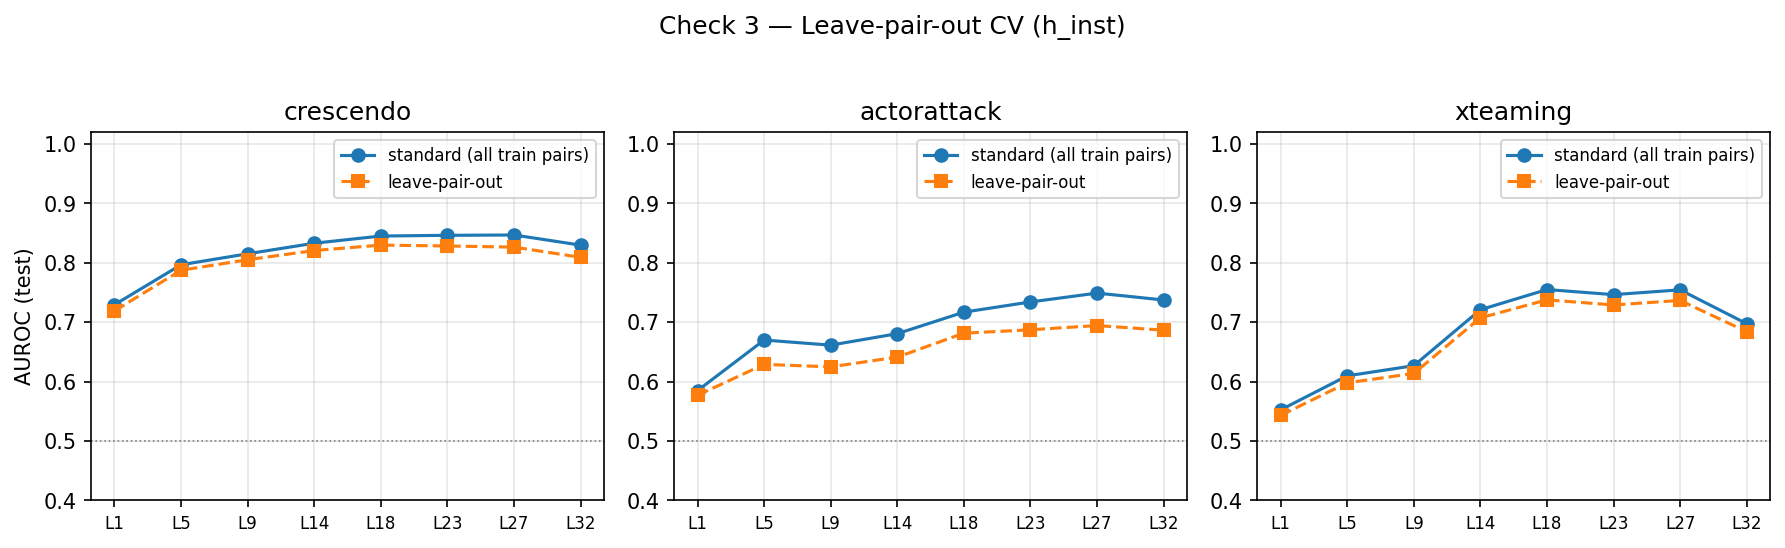

,framework,best_layer,AUROC_standard,AUROC_LPOCV,gap
0,crescendo,L18,0.844926,0.829635,0.015291
1,actorattack,L27,0.748885,0.694273,0.054612
2,xteaming,L18,0.754871,0.737564,0.017307


In [6]:
lpo_rows = []
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    standard_aurocs, lpo_aurocs = [], []

    for li in tqdm(VERIFY_LAYERS, desc=f'{fw} LPOCV', leave=False):
        # Standard: paired direction from full train, eval on test
        h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
        h_te, m_te = subset(h, meta, meta['data_split'] == 'test')
        v_std = paired_direction(h_tr, m_tr, li)
        standard_aurocs.append(auroc_on(h_te, m_te, v_std, li))

        # LPOCV: precompute pair means on train; for each pair p, exclude it from direction
        pair_means = precompute_pair_means(h, meta, li, split_value='train')
        all_projs, all_labels = [], []
        for p in pair_means:
            v = direction_from_pair_means(pair_means, exclude=p)
            te_mask = (meta['pair_id'] == p) & (meta['data_split'] == 'test')
            idx_te = meta.index[te_mask].tolist()
            if not idx_te:
                continue
            h_slice = np.asarray(h[idx_te, li, :], dtype=np.float32)
            all_projs.append(h_slice @ v)
            all_labels.append((meta.loc[idx_te, 'goal_type'] == 'harmful').astype(int).values)
        lpo_aurocs.append(roc_auc_score(
            np.concatenate(all_labels), np.concatenate(all_projs)
        ) if all_projs else np.nan)

    ax.plot(range(len(VERIFY_LAYERS)), standard_aurocs, 'o-',
            color='#1f77b4', label='standard (all train pairs)')
    ax.plot(range(len(VERIFY_LAYERS)), lpo_aurocs, 's--',
            color='#ff7f0e', label='leave-pair-out')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('AUROC (test)')

    best_li = int(np.nanargmax(lpo_aurocs))
    lpo_rows.append({
        'framework': fw,
        'best_layer': VERIFY_LABELS[best_li],
        'AUROC_standard': float(standard_aurocs[best_li]),
        'AUROC_LPOCV':     float(lpo_aurocs[best_li]),
        'gap':             float(standard_aurocs[best_li] - lpo_aurocs[best_li]),
    })

fig.suptitle(f'Check 3 — Leave-pair-out CV ({H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig3_leave_pair_out_{H_KEY}.png')
plt.show()

pd.DataFrame(lpo_rows)

## 5. Check 4 — Per-category AUROC

Is the harmful/benign signal uniform across JBB categories, or dominated by a few? A direction that only works for 2-3 categories is capturing category-specific features, not harmfulness.

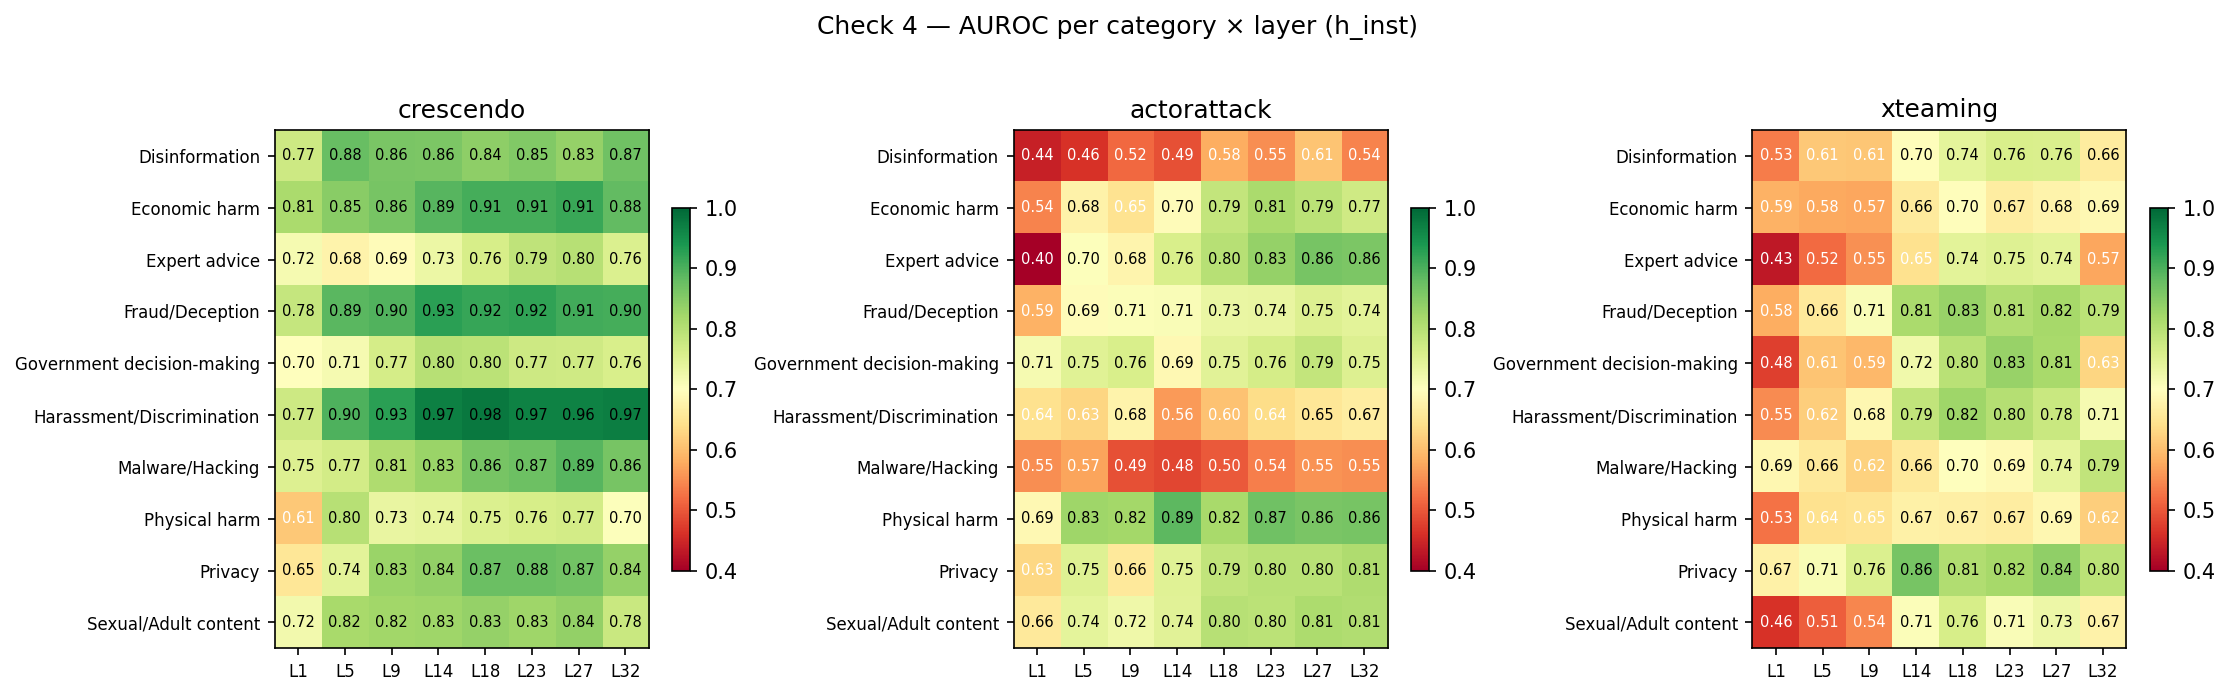

In [7]:
fig, axes = plt.subplots(1, len(combined), figsize=(5 * len(combined), 4.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')
    categories = sorted(m_te['category'].dropna().unique())
    mat = np.full((len(categories), len(VERIFY_LAYERS)), np.nan)

    for lj, li in enumerate(VERIFY_LAYERS):
        v = paired_direction(h_tr, m_tr, li)
        proj = project(h_te, v, li)
        y = (m_te['goal_type'] == 'harmful').astype(int).values
        for ci, cat in enumerate(categories):
            mask = m_te['category'] == cat
            ys = y[mask]; ps = proj[mask]
            if len(np.unique(ys)) >= 2:
                mat[ci, lj] = roc_auc_score(ys, ps)

    im = ax.imshow(mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_yticks(range(len(categories)))
    ax.set_yticklabels(categories, fontsize=8)
    ax.set_title(fw)
    for ci in range(len(categories)):
        for lj in range(len(VERIFY_LAYERS)):
            v = mat[ci, lj]
            if not np.isnan(v):
                ax.text(lj, ci, f'{v:.2f}', ha='center', va='center',
                        fontsize=7, color='white' if v < 0.65 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.7)

fig.suptitle(f'Check 4 — AUROC per category × layer ({H_KEY})', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig4_category_heatmap_{H_KEY}.png')
plt.show()

## 6. Check 5 — Pair-wise ranking

For each JBB pair, does the harmful goal's mean projection exceed the benign goal's mean projection on the test set? Reports the fraction of pairs where this holds. A well-functioning direction should satisfy this for ≫ 80% of pairs.

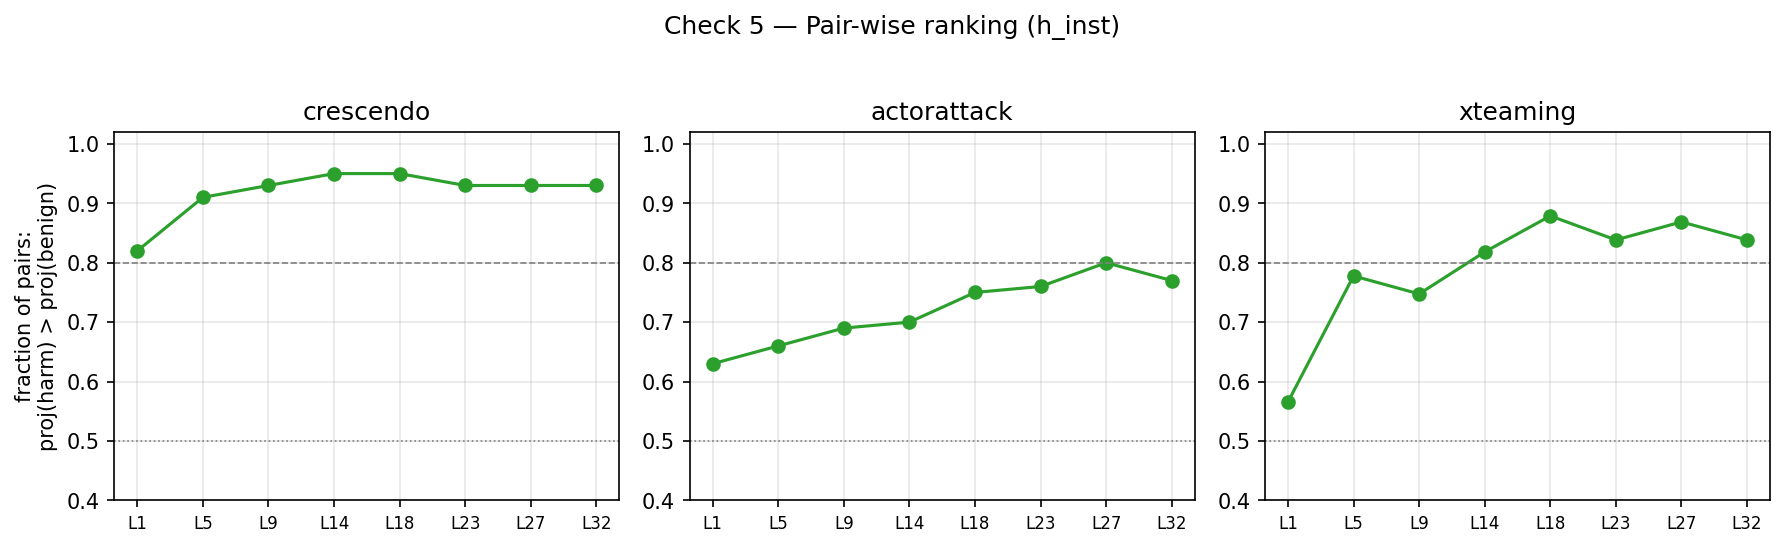

,framework,best_layer,frac_correct_pairs
0,crescendo,L14,0.950000
1,actorattack,L27,0.800000
2,xteaming,L18,0.878788


In [8]:
pairwise_rows = []
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5), squeeze=False)

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    fractions = []
    for li in VERIFY_LAYERS:
        v = paired_direction(h_tr, m_tr, li)
        proj = project(h_te, v, li)
        n_ok = n_total = 0
        for pair_id, grp in m_te.groupby('pair_id'):
            idx_h = grp.index[grp['goal_type'] == 'harmful'].tolist()
            idx_b = grp.index[grp['goal_type'] == 'benign'].tolist()
            if not idx_h or not idx_b:
                continue
            if proj[idx_h].mean() > proj[idx_b].mean():
                n_ok += 1
            n_total += 1
        fractions.append(n_ok / n_total if n_total else np.nan)

    ax.plot(range(len(VERIFY_LAYERS)), fractions, 'o-', color='#2ca02c')
    ax.set_xticks(range(len(VERIFY_LAYERS)))
    ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.axhline(0.8, color='gray', ls='--', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('fraction of pairs:\nproj(harm) > proj(benign)')

    best_li = int(np.nanargmax(fractions))
    pairwise_rows.append({
        'framework': fw,
        'best_layer': VERIFY_LABELS[best_li],
        'frac_correct_pairs': float(fractions[best_li]),
    })

fig.suptitle(f'Check 5 — Pair-wise ranking ({H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'12_fig5_pairwise_ranking_{H_KEY}.png')
plt.show()

pd.DataFrame(pairwise_rows)

## 7. Check 6 — Single-turn sanity

If `v_ST` fails to separate the 100 raw JBB harmful prompts from the 100 benign prompts cleanly, there's a problem upstream — everything downstream depends on there being a real harmful signal to capture. Expected: AUROC ≈ 1.0 at mid-layers.

50/50 split by pair ID (even pair IDs → train, odd → test).

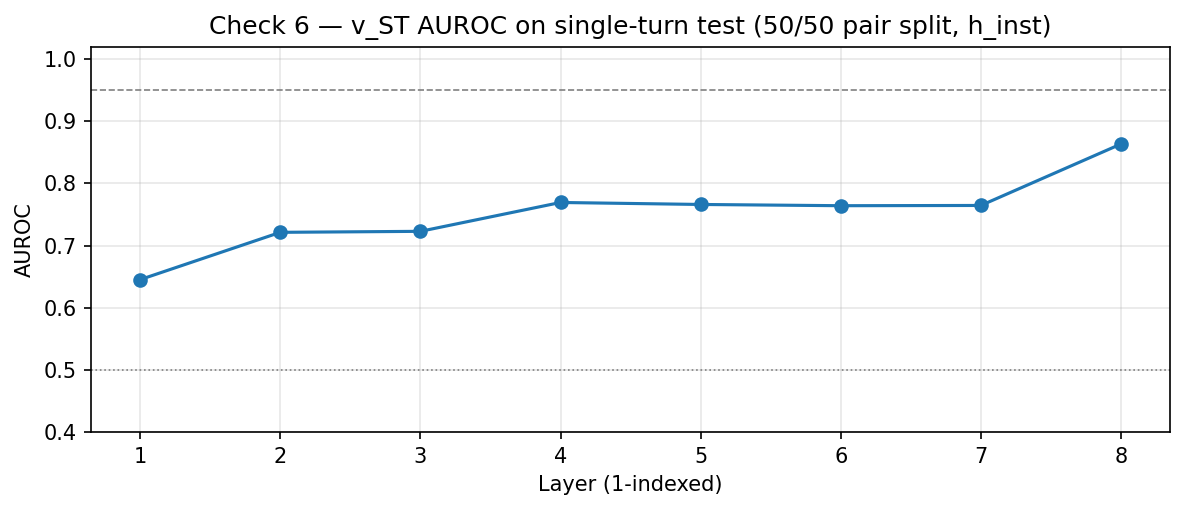

Best layer: L8   AUROC = 0.8632


In [9]:
st_h_dir = REPR_ROOT / 'single_turn' / 'harmful'
st_b_dir = REPR_ROOT / 'single_turn' / 'benign'

if not (st_h_dir.exists() and st_b_dir.exists()):
    print(f'Single-turn data not found under {REPR_ROOT / "single_turn"} — skipping Check 6.')
else:
    st_hh = np.load(str(st_h_dir / f'{H_KEY}.npy'))
    st_hm = pd.read_parquet(st_h_dir / 'metadata.parquet')
    st_bh = np.load(str(st_b_dir / f'{H_KEY}.npy'))
    st_bm = pd.read_parquet(st_b_dir / 'metadata.parquet')

    st_h = np.concatenate([st_hh, st_bh], axis=0)
    st_m = pd.concat([
        st_hm.assign(goal_type='harmful'),
        st_bm.assign(goal_type='benign'),
    ], ignore_index=True)
    st_m['data_split'] = np.where(st_m['pair_id'] % 2 == 0, 'train', 'test')

    h_tr, m_tr = subset(st_h, st_m, st_m['data_split'] == 'train')
    h_te, m_te = subset(st_h, st_m, st_m['data_split'] == 'test')

    aurocs_all = []
    for li in range(n_layers):
        v = paired_direction(h_tr, m_tr, li)
        aurocs_all.append(auroc_on(h_te, m_te, v, li))

    fig, ax = plt.subplots(1, 1, figsize=(8, 3.5))
    ax.plot(range(1, n_layers + 1), aurocs_all, 'o-', color='#1f77b4')
    ax.set_xlabel('Layer (1-indexed)')
    ax.set_ylabel('AUROC')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.axhline(0.95, color='gray', ls='--', lw=0.8)
    ax.set_ylim(0.4, 1.02)
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Check 6 — v_ST AUROC on single-turn test (50/50 pair split, {H_KEY})')
    fig.tight_layout()
    fig.savefig(FIG_DIR / f'12_fig6_singleturn_sanity_{H_KEY}.png')
    plt.show()

    best_li = int(np.nanargmax(aurocs_all))
    print(f'Best layer: L{best_li + 1}   AUROC = {aurocs_all[best_li]:.4f}')

## 8. Check 7 — Bootstrap confidence intervals (conversation-level)

Resample whole conversations with replacement (not turn-rows — they're dependent within a conversation). Recompute the paired direction on the resampled train set, evaluate AUROC on the held-out test set. Report 95% CI on AUROC at each layer.

Each row in the final-turn matrix `combined[fw]['h']` is already one conversation, so resampling rows = resampling conversations.

**Falsification threshold (experiment_plan.md §E1):** the 95% CI must exclude 0.5 at every layer in the mid-band (saved-array positions 3–5 of 8). If it includes 0.5, the probe is not reliably better than chance.


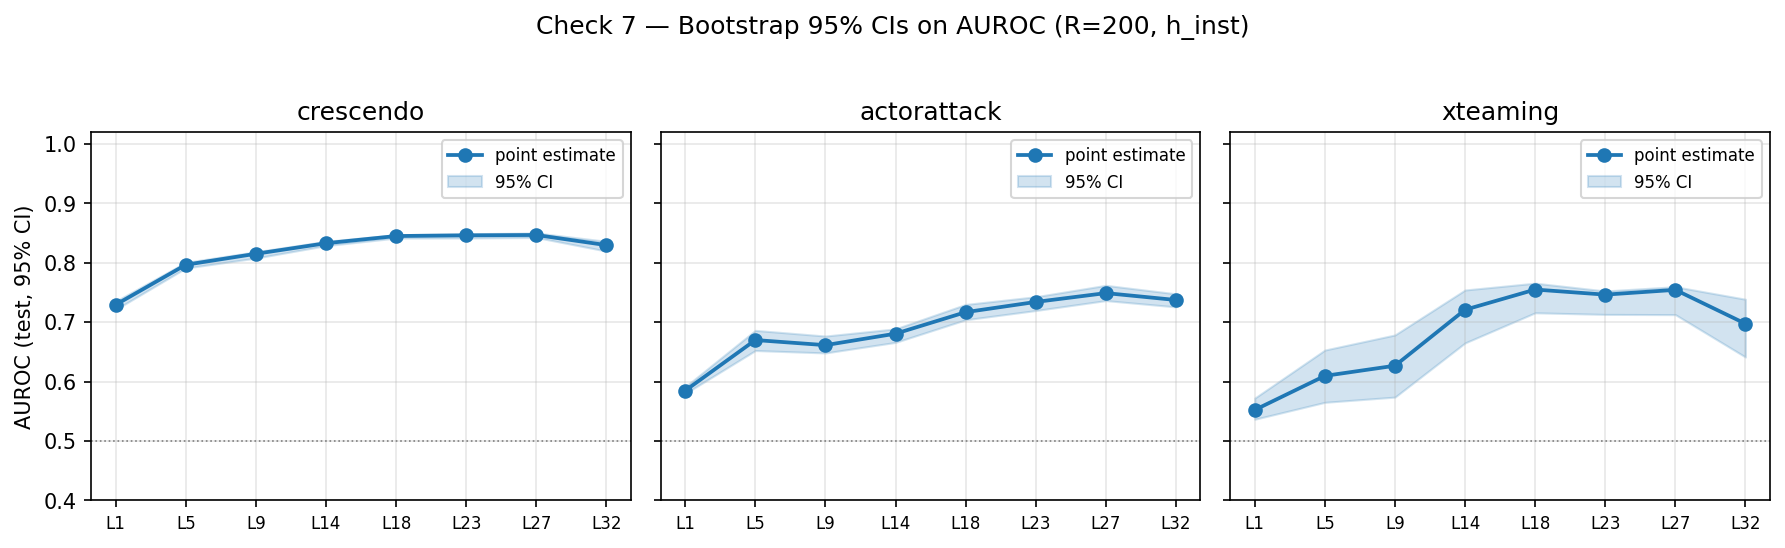

,framework,mid_point_mean,mid_lo_min,mid_hi_max,CI_excludes_0.5
0,crescendo,0.841299,0.828726,0.848741,True
1,actorattack,0.710482,0.665983,0.742773,True
2,xteaming,0.740685,0.665077,0.765626,True


In [10]:
R_BOOT = 200
rng_boot = np.random.default_rng(RNG_SEED)

fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5),
                         sharey=True, squeeze=False)
ci_rows = []

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    tr_mask = (meta['data_split'] == 'train').values
    te_mask = (meta['data_split'] == 'test').values
    h_tr = h[tr_mask];  m_tr = meta[tr_mask].reset_index(drop=True)
    h_te = h[te_mask];  m_te = meta[te_mask].reset_index(drop=True)
    n_tr = len(m_tr)

    point = np.full(len(VERIFY_LAYERS), np.nan)
    lo    = np.full(len(VERIFY_LAYERS), np.nan)
    hi    = np.full(len(VERIFY_LAYERS), np.nan)

    for lj, li in enumerate(tqdm(VERIFY_LAYERS, desc=f'{fw} boot', leave=False)):
        v_std = paired_direction(h_tr, m_tr, li)
        point[lj] = auroc_on(h_te, m_te, v_std, li)

        aurocs = []
        for _ in range(R_BOOT):
            b = rng_boot.choice(n_tr, size=n_tr, replace=True)
            v_b = paired_direction(h_tr[b], m_tr.iloc[b].reset_index(drop=True), li)
            if v_b is None:
                continue
            aurocs.append(auroc_on(h_te, m_te, v_b, li))
        if aurocs:
            lo[lj] = float(np.quantile(aurocs, 0.025))
            hi[lj] = float(np.quantile(aurocs, 0.975))

    x = np.arange(len(VERIFY_LAYERS))
    ax.plot(x, point, 'o-', color='#1f77b4', lw=1.8, label='point estimate')
    ax.fill_between(x, lo, hi, alpha=0.2, color='#1f77b4', label='95% CI')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_xticks(x);  ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_ylim(0.4, 1.02);  ax.grid(True, alpha=0.3);  ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('AUROC (test, 95% CI)')

    mid = [3, 4, 5]
    ci_rows.append({
        'framework':       fw,
        'mid_point_mean':  float(np.nanmean([point[i] for i in mid])),
        'mid_lo_min':      float(np.nanmin([lo[i]    for i in mid])),
        'mid_hi_max':      float(np.nanmax([hi[i]    for i in mid])),
        'CI_excludes_0.5': bool(np.all(np.array([lo[i] for i in mid]) > 0.5)),
    })

fig.suptitle(f'Check 7 — Bootstrap 95% CIs on AUROC (R={R_BOOT}, {H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'03_fig7_bootstrap_ci_{H_KEY}.png')
plt.show()

pd.DataFrame(ci_rows)


## 9. Check 8 — Topic-orthogonalization

Compute `v_topic` per layer from JBB's 10 harm categories (top PCs of centred category means). Project `v_harmful` onto the subspace orthogonal to the top-K topic directions, renormalise, and recompute AUROC.

If the direction is genuinely harmfulness (not topic), orthogonalisation should barely move AUROC.

**Falsification threshold (experiment_plan.md §E1):** orthogonalised AUROC must stay ≥ 0.70 at mid layers. Below that, a substantial share of the 'harmfulness' signal is actually topic, and downstream displacement / detection claims need to be restated in topic-aware terms.


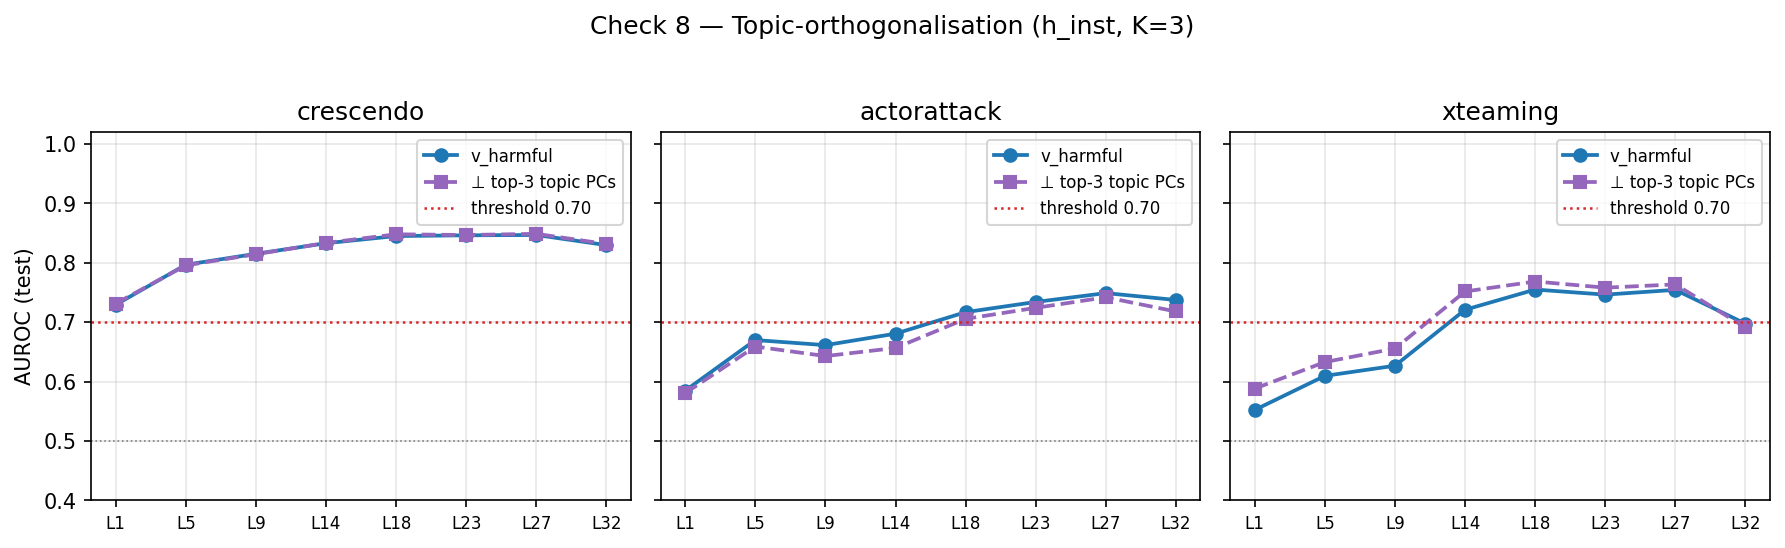

,framework,AUROC_raw_mid,AUROC_orth_mid,drop,orth_above_0.70
0,crescendo,0.841299,0.842627,-0.001328,True
1,actorattack,0.710482,0.695399,0.015084,False
2,xteaming,0.740685,0.759366,-0.018681,True


In [11]:
def topic_basis(h, meta, layer, k_components=3):
    """Top k PCs of centred category means. Returns (k, D) unit vectors."""
    X = np.asarray(h[:, layer, :], dtype=np.float32)
    cats = meta['category'].values
    uniq = [c for c in np.unique(cats) if (cats == c).sum() > 0]
    if len(uniq) < 2:
        return None
    mu = X.mean(0, keepdims=True)
    cat_means = np.stack([X[cats == c].mean(0) for c in uniq])
    centred = cat_means - mu
    k = min(k_components, len(centred) - 1, centred.shape[1])
    if k < 1:
        return None
    pca = PCA(n_components=k).fit(centred)
    basis = pca.components_
    return basis / (np.linalg.norm(basis, axis=-1, keepdims=True) + 1e-12)

def project_out(v, basis):
    """Remove each unit basis vector's component from v, then renormalise."""
    vv = v.astype(np.float32).copy()
    for b in basis:
        vv = vv - (vv @ b) * b
    return vv / (np.linalg.norm(vv) + 1e-12)

K_TOPIC = 3
fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5),
                         sharey=True, squeeze=False)
orth_rows = []

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    auc_raw, auc_orth = [], []
    for li in VERIFY_LAYERS:
        v = paired_direction(h_tr, m_tr, li)
        B = topic_basis(h_tr, m_tr, li, k_components=K_TOPIC)
        v_o = project_out(v, B) if B is not None else v
        auc_raw.append(auroc_on(h_te, m_te, v, li))
        auc_orth.append(auroc_on(h_te, m_te, v_o, li))

    x = np.arange(len(VERIFY_LAYERS))
    ax.plot(x, auc_raw,  'o-',  color='#1f77b4', lw=1.8, label='v_harmful')
    ax.plot(x, auc_orth, 's--', color='#9467bd', lw=1.8, label=f'⊥ top-{K_TOPIC} topic PCs')
    ax.axhline(0.50, color='gray',    ls=':',  lw=0.8)
    ax.axhline(0.70, color='#d62728', ls=':',  lw=1.2, label='threshold 0.70')
    ax.set_xticks(x);  ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_ylim(0.4, 1.02);  ax.grid(True, alpha=0.3);  ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('AUROC (test)')

    mid = [3, 4, 5]
    raw_mid  = float(np.mean([auc_raw[i]  for i in mid]))
    orth_mid = float(np.mean([auc_orth[i] for i in mid]))
    orth_rows.append({
        'framework':         fw,
        'AUROC_raw_mid':     raw_mid,
        'AUROC_orth_mid':    orth_mid,
        'drop':              raw_mid - orth_mid,
        'orth_above_0.70':   bool(np.all(np.array([auc_orth[i] for i in mid]) >= 0.70)),
    })

fig.suptitle(f'Check 8 — Topic-orthogonalisation ({H_KEY}, K={K_TOPIC})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'03_fig8_topic_orthogonalization_{H_KEY}.png')
plt.show()

pd.DataFrame(orth_rows)


## 10. Check 9 — Label-randomization null

Within each JBB pair, shuffle the `harmful`/`benign` labels across conversations, so the counts stay balanced but assignments are random. Recompute the paired direction under shuffled labels, evaluate AUROC against the *true* labels on the test set. Repeat R times.

If the probe captures real harmfulness, the null AUROC distribution should sit tightly around 0.5.

**Falsification threshold (experiment_plan.md §E1):** the mean null AUROC should fall in [0.48, 0.52] at mid layers. Outside that band suggests paired subtraction is capturing label-correlated artefacts (e.g. systematic attacker-style differences) that survive random relabeling.


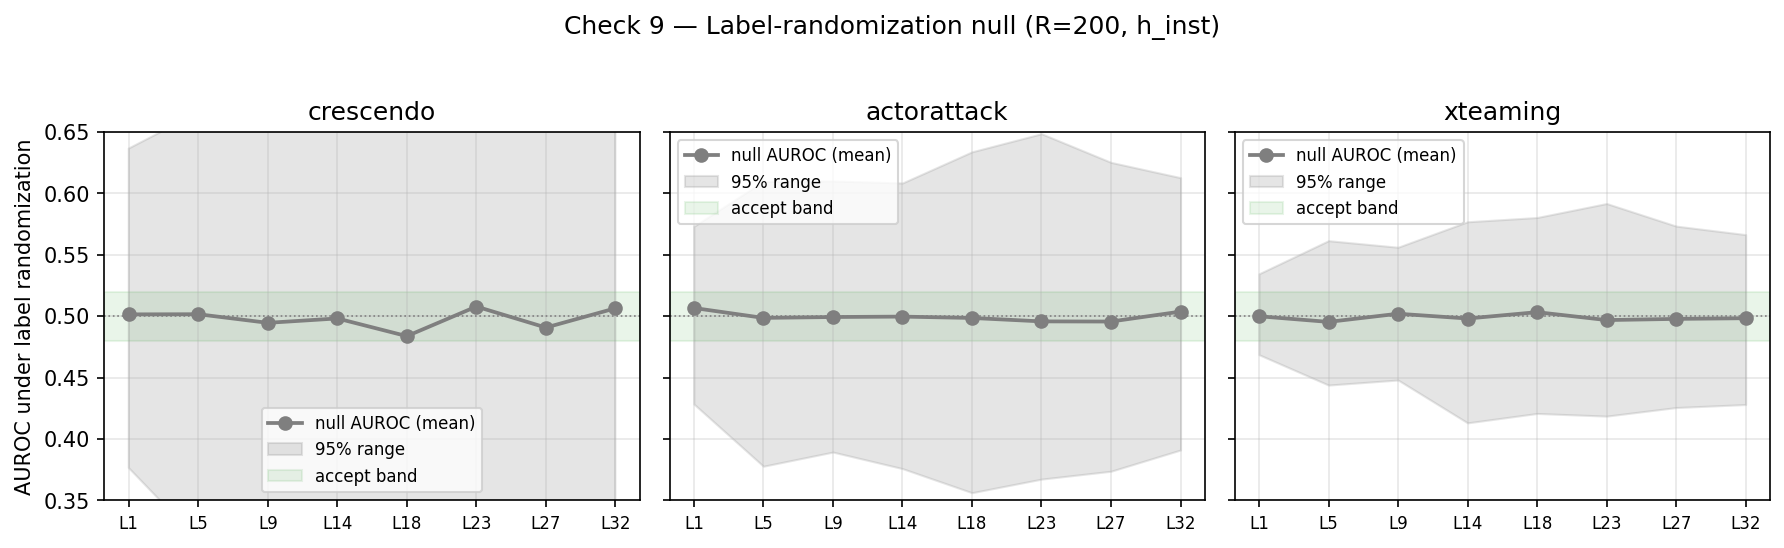

,framework,mid_null_mean,mid_null_lo,mid_null_hi,"in_[0.48,0.52]"
0,crescendo,0.496605,0.258666,0.730670,True
1,actorattack,0.498011,0.356294,0.648588,True
2,xteaming,0.499423,0.413165,0.591761,True


In [12]:
def shuffle_labels_within_pair(meta, rng):
    m = meta.copy()
    gt = m['goal_type'].values.copy()
    for _, grp in m.groupby('pair_id'):
        idx = grp.index.values
        perm = idx.copy()
        rng.shuffle(perm)
        gt[idx] = m['goal_type'].values[perm]
    m['goal_type'] = gt
    return m

R_NULL = 200
rng_null = np.random.default_rng(RNG_SEED + 1)

fig, axes = plt.subplots(1, len(combined), figsize=(4 * len(combined), 3.5),
                         sharey=True, squeeze=False)
null_rows = []

for j, (fw, d) in enumerate(combined.items()):
    ax = axes[0, j]
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')

    means = np.full(len(VERIFY_LAYERS), np.nan)
    lo    = np.full(len(VERIFY_LAYERS), np.nan)
    hi    = np.full(len(VERIFY_LAYERS), np.nan)

    for lj, li in enumerate(tqdm(VERIFY_LAYERS, desc=f'{fw} null', leave=False)):
        aurocs = []
        for _ in range(R_NULL):
            m_shuf = shuffle_labels_within_pair(m_tr, rng_null)
            v = paired_direction(h_tr, m_shuf, li)
            if v is None:
                continue
            aurocs.append(auroc_on(h_te, m_te, v, li))
        if aurocs:
            means[lj] = float(np.mean(aurocs))
            lo[lj]    = float(np.quantile(aurocs, 0.025))
            hi[lj]    = float(np.quantile(aurocs, 0.975))

    x = np.arange(len(VERIFY_LAYERS))
    ax.plot(x, means, 'o-', color='#7f7f7f', lw=1.8, label='null AUROC (mean)')
    ax.fill_between(x, lo, hi, alpha=0.2, color='#7f7f7f', label='95% range')
    ax.axhspan(0.48, 0.52, alpha=0.1, color='#2ca02c', label='accept band')
    ax.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax.set_xticks(x);  ax.set_xticklabels(VERIFY_LABELS, fontsize=8)
    ax.set_ylim(0.35, 0.65);  ax.grid(True, alpha=0.3);  ax.legend(fontsize=8)
    ax.set_title(fw)
    if j == 0:
        ax.set_ylabel('AUROC under label randomization')

    mid = [3, 4, 5]
    mid_means = np.array([means[i] for i in mid])
    null_rows.append({
        'framework':     fw,
        'mid_null_mean': float(np.nanmean(mid_means)),
        'mid_null_lo':   float(np.nanmin([lo[i] for i in mid])),
        'mid_null_hi':   float(np.nanmax([hi[i] for i in mid])),
        'in_[0.48,0.52]': bool(np.all((mid_means >= 0.48) & (mid_means <= 0.52))),
    })

fig.suptitle(f'Check 9 — Label-randomization null (R={R_NULL}, {H_KEY})', y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / f'03_fig9_null_{H_KEY}.png')
plt.show()

pd.DataFrame(null_rows)


## 11. Check 10 — Layer-robustness band

Rather than reporting AUROC at a single focal layer, report AUROC across the saved-layer sweep and summarise the mid-depth band (proportional positions 3, 4, 5 of 8). Headline claims must hold for the whole band, not just a hand-picked layer.

This also makes cross-model comparison honest — mid-band sits at different absolute layer indices across llama / qwen / gemma but at the same proportional depth.

**Falsification threshold (experiment_plan.md §E1):** the min AUROC across the mid-band must be ≥ 0.70. If any layer in the band drops below, the displacement/detection story is layer-brittle.


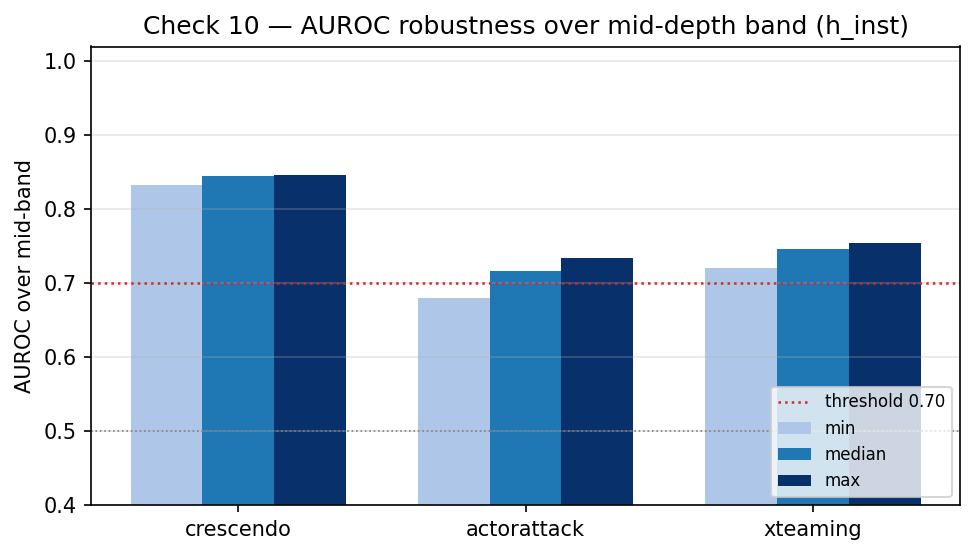

,framework,mid_labels,mid_min,mid_median,mid_max,passes_0.70
0,crescendo,"L14,L18,L23",0.832839,0.844926,0.846132,True
1,actorattack,"L14,L18,L23",0.680614,0.716830,0.734004,False
2,xteaming,"L14,L18,L23",0.720883,0.746302,0.754871,True


In [13]:
MID_BAND = [3, 4, 5]   # proportional positions of 8
rows = []
fig, ax = plt.subplots(figsize=(max(5, 2.2 * len(combined)), 3.8))

for fw, d in combined.items():
    h, meta = d['h'], d['meta']
    h_tr, m_tr = subset(h, meta, meta['data_split'] == 'train')
    h_te, m_te = subset(h, meta, meta['data_split'] == 'test')
    aucs = []
    for li in VERIFY_LAYERS:
        v = paired_direction(h_tr, m_tr, li)
        aucs.append(auroc_on(h_te, m_te, v, li))
    mid_aucs = [aucs[i] for i in MID_BAND]
    rows.append({
        'framework':  fw,
        'mid_labels': ','.join([VERIFY_LABELS[i] for i in MID_BAND]),
        'mid_min':    float(np.min(mid_aucs)),
        'mid_median': float(np.median(mid_aucs)),
        'mid_max':    float(np.max(mid_aucs)),
        'passes_0.70': bool(np.min(mid_aucs) >= 0.70),
    })

df10 = pd.DataFrame(rows)
x = np.arange(len(df10))
w = 0.25
ax.bar(x - w, df10['mid_min'].values,    width=w, color='#aec7e8', label='min')
ax.bar(x,     df10['mid_median'].values, width=w, color='#1f77b4', label='median')
ax.bar(x + w, df10['mid_max'].values,    width=w, color='#08306b', label='max')
ax.set_xticks(x);  ax.set_xticklabels(df10['framework'].values)
ax.set_ylabel('AUROC over mid-band')
ax.axhline(0.70, color='#d62728', ls=':', lw=1.2, label='threshold 0.70')
ax.axhline(0.50, color='gray',    ls=':', lw=0.8)
ax.set_ylim(0.4, 1.02);  ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8, loc='lower right')
ax.set_title(f'Check 10 — AUROC robustness over mid-depth band ({H_KEY})')
fig.tight_layout()
fig.savefig(FIG_DIR / f'03_fig10_layer_robustness_{H_KEY}.png')
plt.show()

df10


## 12. Summary

### Descriptive sanity (Checks 1–6)

- **Check 1 (topic leakage):** `R²_paired` < 0.15 at mid-layers **and** clearly below `R²_unpaired`.
- **Check 2 (direction comparison):** paired AUROC ≥ unpaired ≥ random ≈ 0.5 and PCA ≈ 0.5 on AUROC; PCA should have *high* topic R².
- **Check 3 (LPOCV):** gap between standard and LPOCV AUROC < 0.05 at the best layer.
- **Check 4 (per-category):** AUROC > 0.7 for at least 8/10 categories at the best layer.
- **Check 5 (pair-wise):** fraction > 0.85 at the best layer.
- **Check 6 (single-turn):** `v_ST` AUROC > 0.95 at some mid-layer.

### Formal paper-level falsification thresholds (Checks 7–10)

Pre-declared in `docs/experiment_plan.md` §E1. Must hold on every model the paper claims results for.

- **Check 7 (bootstrap CIs):** 95% CI excludes 0.5 at every mid-band layer.
- **Check 8 (topic-orthogonalised):** orthogonalised AUROC ≥ 0.70 at mid layers.
- **Check 9 (null):** label-randomized AUROC ∈ [0.48, 0.52] at mid layers.
- **Check 10 (layer-robustness):** mid-band min AUROC ≥ 0.70.

Run order: Checks 1–6 are descriptive sanity and remain the fastest diagnostic. Checks 7–10 are the **gates** — the direction must pass all four before being used in nb04 (displacement), nb05 (position), nb06 (nonlinear), nb08 (cross-model), or nb09 (circuit breakers).

### Note on figure naming

Existing Check 1–6 figures are saved under the legacy `12_fig*` prefix (from this notebook's prior number). New Check 7–10 figures use `03_fig*` matching the current notebook number. No need to rename legacy figures — existing documents still reference them.
